# Capstone Black Box Project

## Function 6 - Cake Recipe

optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design.

## Submission 10 of 13

In [8]:
# Required imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern, WhiteKernel
import warnings
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import norm
from scipy.stats.qmc import LatinHypercube
from scipy.spatial.distance import cdist
import math

import sys
sys.path.append('./Utils')
from plot_progress import plot_progress
from plot_input_pairs import plot_nd_projection_matrix

## 1. Load Data

In [2]:
# Load the Input(X) and Output(y) data from the Black Box function's .npy files

function = "function_6"

def load_npy_files(function_name):
    inputs = np.load(f'./Data/{function_name}/merged_inputs.npy')
    outputs = np.load(f'./Data/{function_name}/merged_outputs.npy')
    return inputs, outputs

X, y = load_npy_files(function)

print(f"n = {len(y)}")
print(X[-2:])
print(y[-2:])


n = 29
[[0.519116 0.051684 0.666052 0.678189 0.121254]
 [0.517446 0.167864 0.661411 0.665938 0.143036]]
[-0.49723371 -0.49004208]


## 2. Describe and Review Data

In [3]:
# Review the inputs and outputs
dfX = pd.DataFrame(X)
print(dfX.describe())
dfy = pd.DataFrame(y)
print(dfy.describe())


               0          1          2          3          4
count  29.000000  29.000000  29.000000  29.000000  29.000000
mean    0.511802   0.443181   0.492658   0.610061   0.336496
std     0.265315   0.306834   0.272713   0.266849   0.281927
min     0.021735   0.001566   0.016523   0.045613   0.004911
25%     0.376789   0.167864   0.341819   0.434207   0.112433
50%     0.517790   0.331802   0.544111   0.678189   0.236272
75%     0.729523   0.748106   0.673662   0.756238   0.593103
max     0.957740   0.931871   0.978806   0.961656   0.892819
               0
count  29.000000
mean   -1.220920
std     0.576833
min    -2.571170
25%    -1.672200
50%    -1.233786
75%    -0.714265
max    -0.413858


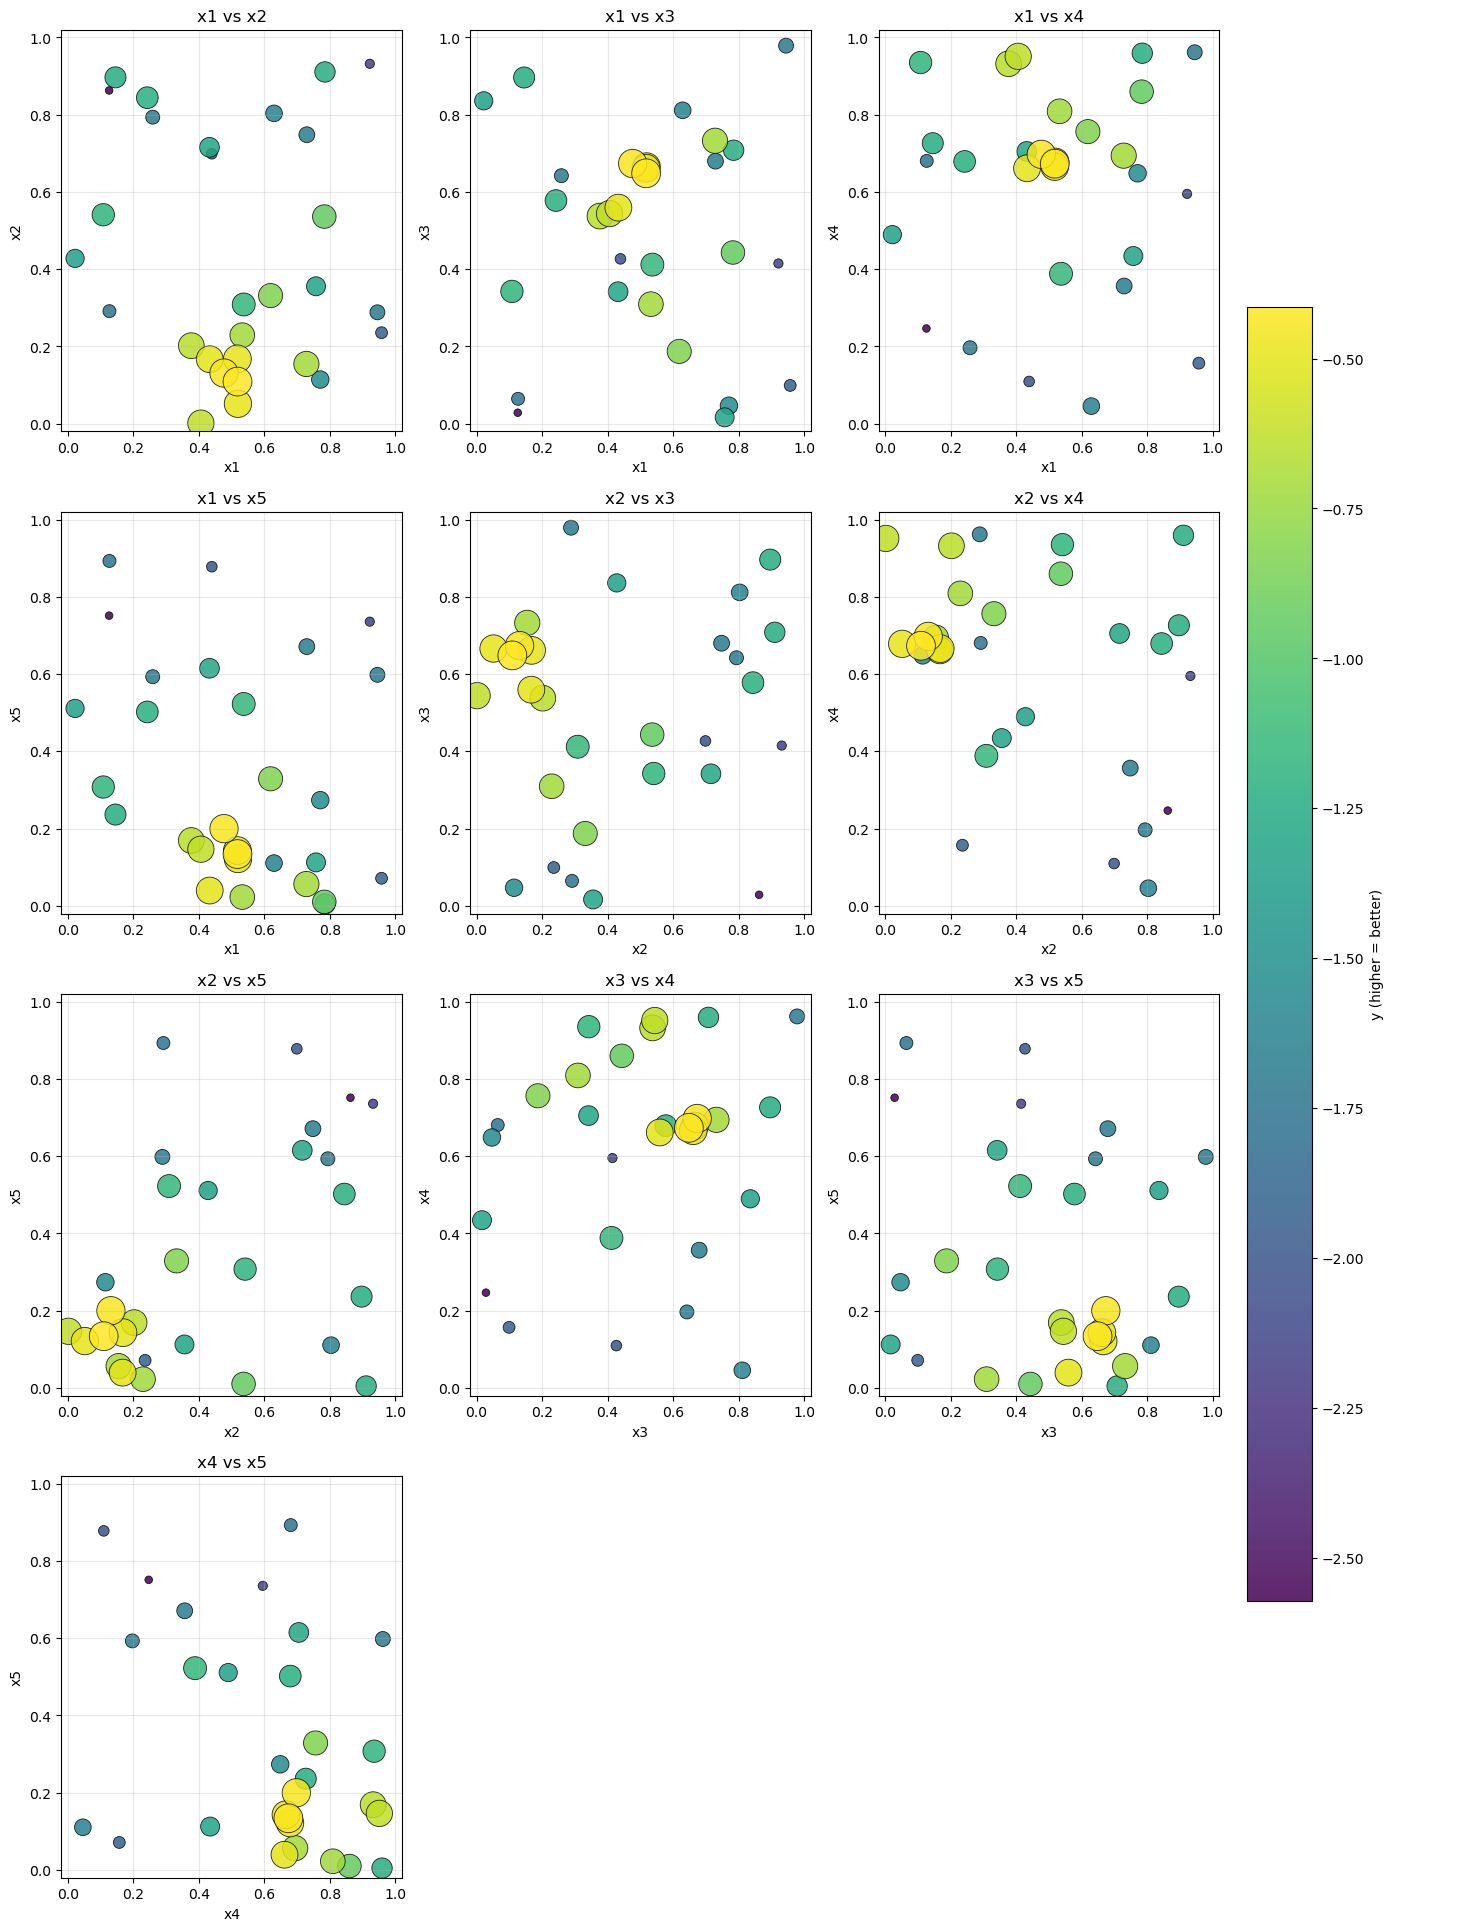

In [9]:
from scipy.stats import rankdata
from itertools import combinations

ridge_idx = np.where(y > 0)[0]   # or however you identify the ridge cluster
fig, axes = plot_nd_projection_matrix(X, y, highlight_idx=ridge_idx)
plt.savefig('./Figures/Function6_projection_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Transform Data

In [10]:
# No transforms applied

y_fit = y

df_y = pd.DataFrame({
    "X1": X[:,0],
    "X2": X[:,1],
    "X3": X[:,2],
    "X4": X[:,3],
    "X5": X[:,4],
    "y": y,
    "y_fit": y_fit
})

output_file = f'./initial_data/{function}/y_transformations.csv'
df_y.to_csv(output_file, index=False)

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'function_6 — y_fit progression with running best'}, xlabel='Iteration (submission number)', ylabel='y_fit'>)

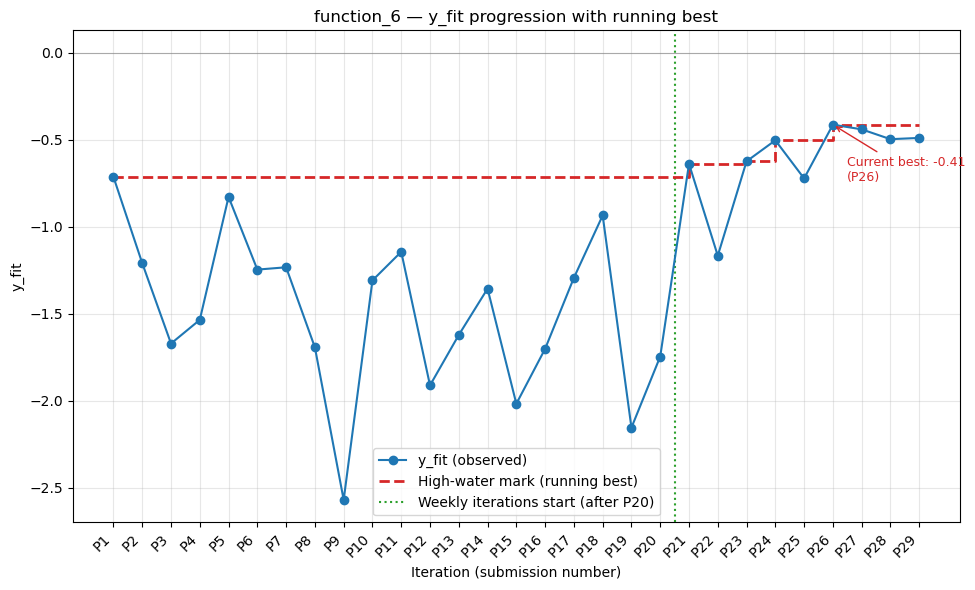

In [11]:
# Point labels and y_fit values to monitor progress
plot_progress(y_fit, labels=None, iteration_start=20, maximize=True,
                   objective_label="y_fit", function_name=function,
                   save_path=None)

## 4. Fit Data to Kernal

In [12]:
# Compare alternative kernels

kernels = {
    'Matern_2.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=2.5),
    'Matern_1.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=1.5),
    'Matern_0.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=0.5),
    # single scalar — isotropic
    'RBF1':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.3, length_scale_bounds=(0.05, 2.0)), #Pre wk 5
    'RBF2':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.25, 2.0)), 
    'RBF3':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.01, 10.0)), 
    'RBF4':        ConstantKernel(1.0, (0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.01, 10.0))
                    + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0)),
    'RBF5':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=np.ones(X.shape[1]),length_scale_bounds=(0.05, 2.0)), 
    'RBF6': ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(0.05, 2.0))
                    + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0)),
}

for name, k in kernels.items():
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always", category=ConvergenceWarning)
        gpr_test = GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=20, random_state=42)
        gpr_test.fit(X, y_fit)
    k_fitted = gpr_test.kernel_
    lml = gpr_test.log_marginal_likelihood_value_
    n_params = len(k_fitted.theta)
    aic = -2 * lml + 2 * n_params
    bic = -2 * lml + n_params * np.log(len(y))
    print(f"{name:12s}  LML={lml:.4f}  AIC={aic:.4f}  BIC={bic:.4f}  kernel={k_fitted}")

Matern_2.5    LML=-24.8093  AIC=53.6186  BIC=56.3532  kernel=0.892**2 * Matern(length_scale=0.444, nu=2.5)
Matern_1.5    LML=-22.1885  AIC=48.3771  BIC=51.1117  kernel=1.06**2 * Matern(length_scale=0.754, nu=1.5)
Matern_0.5    LML=-22.6887  AIC=49.3774  BIC=52.1119  kernel=1.08**2 * Matern(length_scale=2, nu=0.5)
RBF1          LML=-27.0860  AIC=58.1721  BIC=60.9067  kernel=0.88**2 * RBF(length_scale=0.313)
RBF2          LML=-27.0860  AIC=58.1721  BIC=60.9067  kernel=0.88**2 * RBF(length_scale=0.313)
RBF3          LML=-27.0860  AIC=58.1721  BIC=60.9067  kernel=0.88**2 * RBF(length_scale=0.313)
RBF4          LML=-19.8286  AIC=45.6572  BIC=49.7591  kernel=1.08**2 * RBF(length_scale=0.571) + WhiteKernel(noise_level=0.00481)
RBF5          LML=-20.4965  AIC=52.9930  BIC=61.1968  kernel=0.96**2 * RBF(length_scale=[0.494, 0.215, 0.405, 0.652, 2])
RBF6          LML=-17.8109  AIC=49.6218  BIC=59.1929  kernel=1.81**2 * RBF(length_scale=[0.606, 1.08, 1.56, 1.08, 2]) + WhiteKernel(noise_level=0.026

In [14]:
# Fit Gaussian Process
# Select the best kernel for fitting

kernel = kernels['Matern_1.5']

gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
gpr.fit(X, y_fit)
print(gpr.kernel_)

print(f"LML:       {gpr.log_marginal_likelihood_value_:.4f}")

1.06**2 * Matern(length_scale=0.754, nu=1.5)
LML:       -22.1885


In [15]:
# Prediction Grid - Generate candidates and predict y

n_candidates = 10000
low = np.zeros(X.shape[1])
high = np.ones(X.shape[1])

rng = np.random.default_rng(42)
grid = rng.uniform(
low=low,
high=high,
    
size=(n_candidates, X.shape[1]))

print("Shape:", grid.shape)
print("Dimensions:", grid.ndim)
print("\nFirst 5 rows:")
print(grid[:5])
    
# GP predictions
mu, sigma = gpr.predict(grid, return_std=True)


Shape: (10000, 5)
Dimensions: 2

First 5 rows:
[[0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]
 [0.97562235 0.7611397  0.78606431 0.12811363 0.45038594]
 [0.37079802 0.92676499 0.64386512 0.82276161 0.4434142 ]
 [0.22723872 0.55458479 0.06381726 0.82763117 0.6316644 ]
 [0.75808774 0.35452597 0.97069802 0.89312112 0.7783835 ]]


## 5. Define Acquisition Function

In [16]:
 
xi_values = {
    "function_6": 0.05,
}

In [17]:
# Expected Improvement acquisition function
y_best = np.max(y_fit)


xi = xi_values.get(function, 0.1)

print(f"Using xi = {xi} for {function}")

improvement = mu - y_best - xi
Z = improvement / sigma

ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
ei[sigma == 0.0] = 0.0

# Pick next point
next_idx = np.argmax(ei)
print("Next Idx: ", next_idx)
next_x = grid[next_idx]

print("Current best y:", y_best)
print("Next point to evaluate:", next_x)
print("Formatted next point to evaluate:", "-".join(f"{x:.6f}" for x in next_x))
print("Expected improvement:", ei[next_idx])

print("Predicted mean:", mu[next_idx])
print("Predicted std:", sigma[next_idx])
print("Improvement:", mu[next_idx] - y_best - xi)

Using xi = 0.05 for function_6
Next Idx:  5945
Current best y: -0.4138577439868034
Next point to evaluate: [0.52743838 0.11956308 0.49142654 0.657011   0.3137863 ]
Formatted next point to evaluate: 0.527438-0.119563-0.491427-0.657011-0.313786
Expected improvement: 0.01965111834932389
Predicted mean: -0.4963222425263081
Predicted std: 0.16470624433001513
Improvement: -0.13246449853950465


In [12]:
# UCB acquisition function

# ---- ACQUISITION: GP-UCB (replaces EI) ----
kappa = 10
ucb = mu + kappa * sigma
 
next_idx = np.argmax(ucb)
 
print(f"\nUsing kappa = {kappa} for function_6")
print("Next Idx: ", next_idx)
print("Current best y:", y_best)
print("Next point to evaluate:", grid[next_idx])
print("UCB value:", ucb[next_idx])
print("Predicted mean:", mu[next_idx])
print("Predicted std:", sigma[next_idx])


Using kappa = 10 for function_6
Next Idx:  5938
Current best y: -0.4138577439868034
Next point to evaluate: [0.01153937 0.28563097 0.01768064 0.00338215 0.0320164 ]
UCB value: 3.65434668740849
Predicted mean: -1.3618934652749988
Predicted std: 0.5016240152683489


In [14]:
#Fuction 6 LHS

x_best = X[np.argmax(y)] 
print("x_best index:", np.argmax(y))
r = 0.10

bounds_low  = np.array([max(0.05, x_best[i] - r) for i in range(5)])
bounds_high = np.array([min(0.95, x_best[i] + r) for i in range(5)])

print("Search bounds:", list(zip(bounds_low, bounds_high)))

sampler = LatinHypercube(d=5, seed=42)
lhs = sampler.random(n=50)
candidates = bounds_low + lhs * (bounds_high - bounds_low)

mu_c, _ = gpr.predict(candidates, return_std=True)
next_x = candidates[np.argmax(mu_c)]
print("r radius:", r)
print("Next point:", next_x)
print("Formatted:", "-".join(f"{x:.6f}" for x in next_x))
print("mu:", mu_c[np.argmax(mu_c)])

x_best index: 25
Search bounds: [(np.float64(0.41779), np.float64(0.61779)), (np.float64(0.05), np.float64(0.20916800000000002)), (np.float64(0.548313), np.float64(0.748313)), (np.float64(0.573249), np.float64(0.773249)), (np.float64(0.05), np.float64(0.23397300000000001))]
r radius: 0.1
Next point: [0.53266446 0.19549995 0.60966533 0.74302087 0.16117894]
Formatted: 0.532664-0.195500-0.609665-0.743021-0.161179
mu: -0.4031267033486481


In [18]:
# Week 9 X2 profile
# x2 profile: sweep x2, hold the other four coords at P26's located optima
base = np.array([0.518, 0.109, 0.648, 0.673, 0.134])   # P26 [x1,x2,x3,x4,x5]

x2_grid = np.linspace(0.02, 0.30, 57)
G = np.tile(base, (len(x2_grid), 1))   # 57 copies of P26
G[:, 1] = x2_grid                      # overwrite column 1 (x2) with the sweep

mu_g, sd_g = gpr.predict(G, return_std=True)

# print the sweep, tagging the three evaluated x2 values on this axis
for x2, m, s in zip(x2_grid, mu_g, sd_g):
    tag = ''
    if abs(x2 - 0.052) < 0.006: tag = '  <- P28 (-0.4972)'
    elif abs(x2 - 0.109) < 0.006: tag = '  <- P26 (-0.4139)'
    elif abs(x2 - 0.131) < 0.006: tag = '  <- P27 (-0.4407)'
    # print every ~0.025 plus the tagged points
    if tag or abs((x2 / 0.025) - round(x2 / 0.025)) < 0.02:
        print(f"x2={x2:.3f}  mu={m:.4f}  sd={s:.4f}{tag}")

imax = int(np.argmax(mu_g))
print(f"\nx2 profile argmax: x2={x2_grid[imax]:.3f}  mu={mu_g[imax]:.4f}  sd={sd_g[imax]:.4f}")
print(f"incumbent P26 mu at x2=0.109: {mu_g[np.argmin(np.abs(x2_grid-0.109))]:.4f}")

x2=0.025  mu=-0.5027  sd=0.0345
x2=0.050  mu=-0.4671  sd=0.0220  <- P28 (-0.4972)
x2=0.055  mu=-0.4601  sd=0.0201  <- P28 (-0.4972)
x2=0.075  mu=-0.4348  sd=0.0134
x2=0.100  mu=-0.4152  sd=0.0043
x2=0.105  mu=-0.4139  sd=0.0021  <- P26 (-0.4139)
x2=0.110  mu=-0.4137  sd=0.0005  <- P26 (-0.4139)
x2=0.115  mu=-0.4146  sd=0.0025  <- P26 (-0.4139)
x2=0.125  mu=-0.4196  sd=0.0062
x2=0.130  mu=-0.4234  sd=0.0077  <- P27 (-0.4407)
x2=0.135  mu=-0.4280  sd=0.0089  <- P27 (-0.4407)
x2=0.150  mu=-0.4452  sd=0.0113
x2=0.175  mu=-0.4795  sd=0.0157
x2=0.200  mu=-0.5141  sd=0.0267
x2=0.225  mu=-0.5477  sd=0.0418
x2=0.250  mu=-0.5802  sd=0.0585
x2=0.275  mu=-0.6118  sd=0.0758
x2=0.300  mu=-0.6425  sd=0.0930

x2 profile argmax: x2=0.110  mu=-0.4137  sd=0.0005
incumbent P26 mu at x2=0.109: -0.4137


In [23]:
#Wk 9
# Basin-optimum centre, with x2 stepped up to the disciplined target

# wk10 x2: 0.150 -> 0.110
centre = np.array([0.510, 0.110, 0.580, 0.680, 0.120])   # x3: 0.660 -> 0.580

# Per-coordinate half-widths. x3 pinned tight (located optimum); x2 modest; others basin-width.
half   = np.array([0.05,  0.015, 0.020, 0.05,  0.05])     # x3 half-width tightened slightly, centred on new peak; 
                                                            #x2: 0.03 -> 0.015, tight around confirmed peak (sweep sd=0.0005 at 0.110)

lo = np.clip(centre - half, 0.0, 1.0)
hi = np.clip(centre + half, 0.0, 1.0)

n_lhs = 80
sampler = LatinHypercube(d=5, seed=42)
cand = lo + sampler.random(n=n_lhs) * (hi - lo)

# duplicate filter (noiseless function: dmin>0.05)
from scipy.spatial.distance import cdist
dmin = cdist(cand, X).min(axis=1)
valid = cand[dmin > 0.05]
print(f"valid candidates: {len(valid)}/{n_lhs}  (dropped {n_lhs-len(valid)})")

mu, sd = gpr.predict(valid, return_std=True)
i = int(np.argmax(mu))
pick = valid[i]

print(f"P29 pick: {pick}")
print(f"Formatted: {'-'.join(f'{v:.6f}' for v in pick)}")
print(f"mu={mu[i]:.4f}  sd={sd[i]:.4f}  (incumbent -0.4139)")
print(f"x2={pick[1]:.3f}  x3={pick[2]:.3f}  (x3 should be ~0.66)")

#What it does and why:

#x3 half-width 0.015 — this is the load-bearing constraint. It confines x3 to 0.645–0.675, straddling the located 0.65–0.66 optimum, so the optimiser physically cannot trade x3 downhill to 0.61 the way the unconstrained LHS did. This is the fix for the arbitrage you caught.
#x2 centred at 0.15, half-width 0.03 → range 0.12–0.18. Lets the search find the best x2 in the disciplined-step zone (past P27's 0.13, short of the raw argmax 0.175) rather than forcing exactly 0.15.
#dmin>0.05 — the noiseless-function duplicate threshold (contrast F4's 0.01); confirm it drops few candidates and the pick isn't a near-repeat of an evaluated point.

#Sanity checks on the output before submitting:

#x3 lands ~0.65–0.67. If it pins to an edge of its narrow box (0.645 or 0.675), the search wants to leave the pinned region — worth noting but the pin is deliberate.
#x2 lands 0.14–0.17. If it rails to the upper edge (0.18), the profile is pulling toward the 0.175 argmax and you're effectively taking the aggressive step anyway — fine, but know it.
#μ ≈ −0.39 to −0.40, sd tight (<0.03). That's the +0.02ish predicted gain at validated confidence.

#Run it and post the pick. If x3 stays put near 0.66 and x2 lands mid-box with a μ around −0.39, that's your clean disciplined P29.

valid candidates: 80/80  (dropped 0)
P29 pick: [0.5029145  0.09857334 0.58421738 0.72029375 0.1604566 ]
Formatted: 0.502914-0.098573-0.584217-0.720294-0.160457
mu=-0.3564  sd=0.0658  (incumbent -0.4139)
x2=0.099  x3=0.584  (x3 should be ~0.66)


In [22]:
#wk 10 - also sweep X
# X3 sweep — EXTENDED to check for turnover, plus historical data check
x3_vals = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50,
                     0.55, 0.60, 0.61, 0.62, 0.63, 0.64, 0.645, 0.648, 0.65,
                     0.655, 0.66, 0.665, 0.67, 0.68, 0.69, 0.70])

base = np.array([0.510, 0.110, None, 0.680, 0.120])

sweep_points = np.array([[base[0], base[1], x3, base[3], base[4]] for x3 in x3_vals])
mu_sweep, sd_sweep = gpr.predict(sweep_points, return_std=True)

print("X3 sweep (extended):")
for x3, mu, sd in zip(x3_vals, mu_sweep, sd_sweep):
    tag = ""
    if abs(x3 - 0.648) < 0.005: tag = " <- P26 (-0.4139)"
    elif abs(x3 - 0.674) < 0.005: tag = " <- P27 (-0.4407)"
    elif abs(x3 - 0.666) < 0.005: tag = " <- P28 (-0.4972)"
    print(f"x3={x3:.3f}  mu={mu:.4f}  sd={sd:.4f}{tag}")

argmax_i = np.argmax(mu_sweep)
print(f"\nx3 profile argmax: x3={x3_vals[argmax_i]:.3f}  mu={mu_sweep[argmax_i]:.4f}  sd={sd_sweep[argmax_i]:.4f}")

# --- Historical data check: any EVALUATED points with low x3? ---
print("\n--- Evaluated points with x3 < 0.55 ---")
low_x3_mask = X[:, 2] < 0.55
if low_x3_mask.sum() > 0:
    for xi, yi in zip(X[low_x3_mask], y[low_x3_mask]):
        print(f"x3={xi[2]:.3f}  full_point={xi}  y={yi:.4f}")
else:
    print("None — no historical coverage below x3=0.55. Sweep below this is pure extrapolation.")

X3 sweep (extended):
x3=0.050  mu=-1.1295  sd=0.2270
x3=0.100  mu=-1.0488  sd=0.2091
x3=0.150  mu=-0.9630  sd=0.1931
x3=0.200  mu=-0.8740  sd=0.1793
x3=0.250  mu=-0.7839  sd=0.1676
x3=0.300  mu=-0.6949  sd=0.1576
x3=0.350  mu=-0.6096  sd=0.1480
x3=0.400  mu=-0.5312  sd=0.1364
x3=0.450  mu=-0.4637  sd=0.1207
x3=0.500  mu=-0.4120  sd=0.0992
x3=0.550  mu=-0.3819  sd=0.0714
x3=0.600  mu=-0.3809  sd=0.0378
x3=0.610  mu=-0.3851  sd=0.0307
x3=0.620  mu=-0.3911  sd=0.0240
x3=0.630  mu=-0.3990  sd=0.0183
x3=0.640  mu=-0.4091  sd=0.0153
x3=0.645  mu=-0.4151  sd=0.0153 <- P26 (-0.4139)
x3=0.648  mu=-0.4189  sd=0.0158 <- P26 (-0.4139)
x3=0.650  mu=-0.4216  sd=0.0164 <- P26 (-0.4139)
x3=0.655  mu=-0.4287  sd=0.0183
x3=0.660  mu=-0.4364  sd=0.0208
x3=0.665  mu=-0.4445  sd=0.0237 <- P28 (-0.4972)
x3=0.670  mu=-0.4529  sd=0.0267 <- P27 (-0.4407)
x3=0.680  mu=-0.4707  sd=0.0330
x3=0.690  mu=-0.4891  sd=0.0395
x3=0.700  mu=-0.5079  sd=0.0462

x3 profile argmax: x3=0.600  mu=-0.3809  sd=0.0378

--- Evalu

## 6. Plots for Uncertainty and Signal Strength 

In [ ]:
# --- Plot ---

